In [233]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/playground-series-s6e4/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e4/train.csv
/kaggle/input/competitions/playground-series-s6e4/test.csv


In [234]:
data=pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/train.csv')

In [235]:
data.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [236]:
data.shape

(630000, 21)

In [237]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  object 
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  object 
 12  Crop_Growth_Stage        630000 non-null  object 
 13  Season                   630000 non-null  object 
 14  Irri

In [238]:
(data.isnull().sum())/len(data)*100

id                         0.0
Soil_Type                  0.0
Soil_pH                    0.0
Soil_Moisture              0.0
Organic_Carbon             0.0
Electrical_Conductivity    0.0
Temperature_C              0.0
Humidity                   0.0
Rainfall_mm                0.0
Sunlight_Hours             0.0
Wind_Speed_kmh             0.0
Crop_Type                  0.0
Crop_Growth_Stage          0.0
Season                     0.0
Irrigation_Type            0.0
Water_Source               0.0
Field_Area_hectare         0.0
Mulching_Used              0.0
Previous_Irrigation_mm     0.0
Region                     0.0
Irrigation_Need            0.0
dtype: float64

In [239]:
data.drop_duplicates(inplace=True)

In [240]:
data.drop('id',axis=1,inplace=True)

In [241]:
cat_col=data.select_dtypes(include=['object']).columns
cat_col

Index(['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season',
       'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region',
       'Irrigation_Need'],
      dtype='object')

In [242]:
for col in cat_col:
    print(f'Unique Values in {col} is {data[col].unique()}')

Unique Values in Soil_Type is ['Loamy' 'Clay' 'Sandy' 'Silt']
Unique Values in Crop_Type is ['Sugarcane' 'Wheat' 'Rice' 'Potato' 'Cotton' 'Maize']
Unique Values in Crop_Growth_Stage is ['Sowing' 'Vegetative' 'Flowering' 'Harvest']
Unique Values in Season is ['Zaid' 'Kharif' 'Rabi']
Unique Values in Irrigation_Type is ['Drip' 'Rainfed' 'Sprinkler' 'Canal']
Unique Values in Water_Source is ['Rainwater' 'River' 'Reservoir' 'Groundwater']
Unique Values in Mulching_Used is ['No' 'Yes']
Unique Values in Region is ['East' 'South' 'North' 'West' 'Central']
Unique Values in Irrigation_Need is ['Low' 'Medium' 'High']


In [243]:
data.head()

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


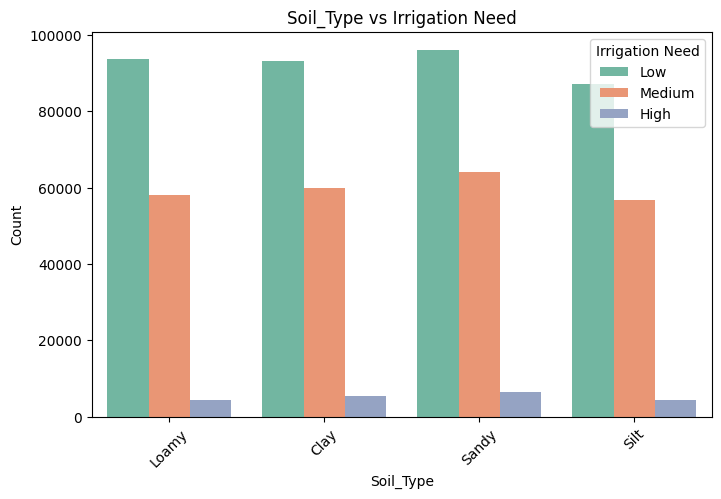

In [244]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 5))
sns.countplot(data=data,x='Soil_Type', hue='Irrigation_Need', palette='Set2')
plt.title('Soil_Type vs Irrigation Need')
plt.xlabel('Soil_Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Irrigation Need')
plt.show()

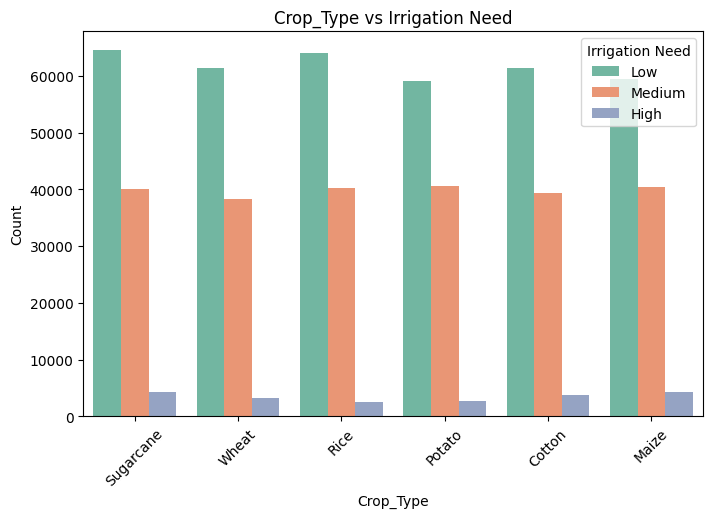

In [245]:
plt.figure(figsize=(8, 5))
sns.countplot(data=data,x='Crop_Type', hue='Irrigation_Need', palette='Set2')
plt.title('Crop_Type vs Irrigation Need')
plt.xlabel('Crop_Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Irrigation Need')
plt.show()

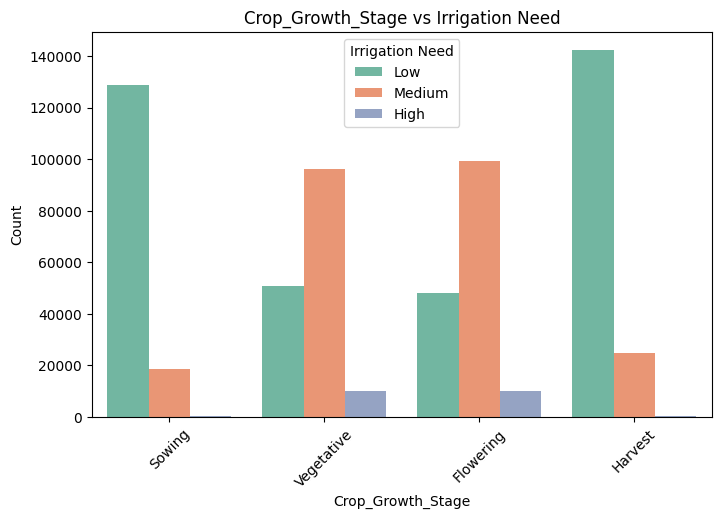

In [246]:
plt.figure(figsize=(8, 5))
sns.countplot(data=data,x='Crop_Growth_Stage', hue='Irrigation_Need', palette='Set2')
plt.title('Crop_Growth_Stage vs Irrigation Need')
plt.xlabel('Crop_Growth_Stage')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Irrigation Need')
plt.show()

In [247]:
data['growth_stage_group'] = data['Crop_Growth_Stage'].map({
    'Sowing': 0,
    'Harvest': 0,
    'Vegetative': 1,
    'Flowering': 1
})

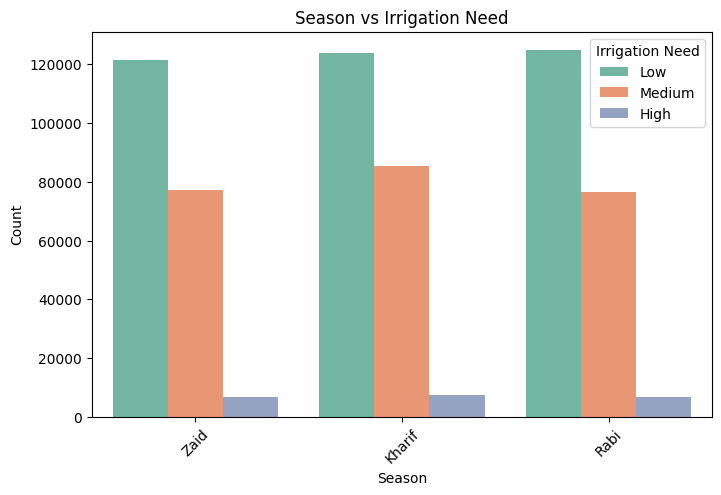

In [248]:
plt.figure(figsize=(8, 5))
sns.countplot(data=data,x='Season', hue='Irrigation_Need', palette='Set2')
plt.title('Season vs Irrigation Need')
plt.xlabel('Season')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Irrigation Need')
plt.show()

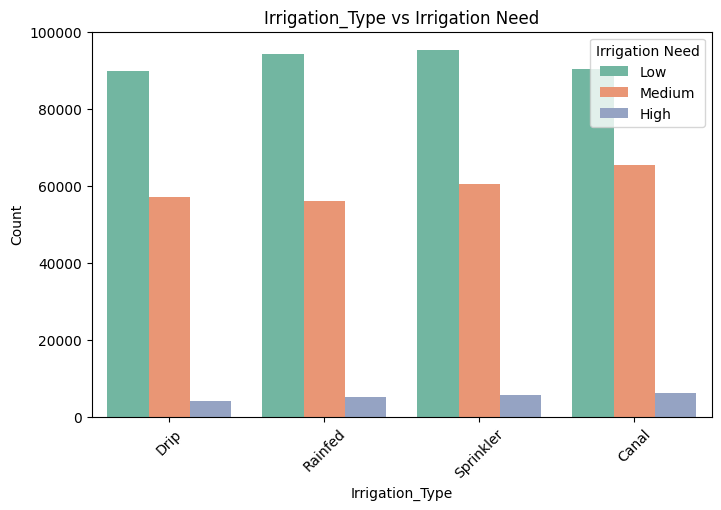

In [249]:
plt.figure(figsize=(8, 5))
sns.countplot(data=data,x='Irrigation_Type', hue='Irrigation_Need', palette='Set2')
plt.title('Irrigation_Type vs Irrigation Need')
plt.xlabel('Irrigation_Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Irrigation Need')
plt.show()

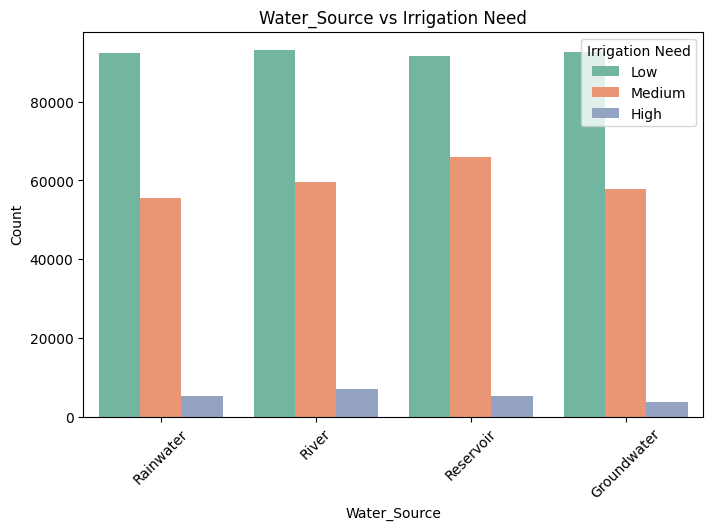

In [250]:
plt.figure(figsize=(8, 5))
sns.countplot(data=data,x='Water_Source', hue='Irrigation_Need', palette='Set2')
plt.title('Water_Source vs Irrigation Need')
plt.xlabel('Water_Source')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Irrigation Need')
plt.show()

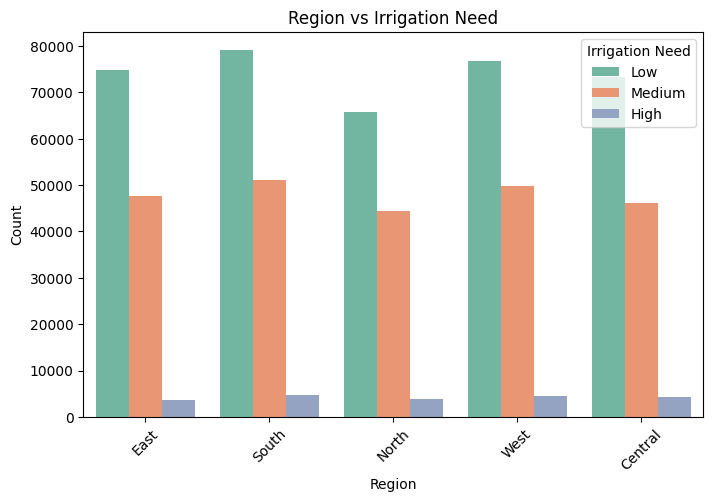

In [251]:
plt.figure(figsize=(8, 5))
sns.countplot(data=data,x='Region', hue='Irrigation_Need', palette='Set2')
plt.title('Region vs Irrigation Need')
plt.xlabel('Region')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Irrigation Need')
plt.show()

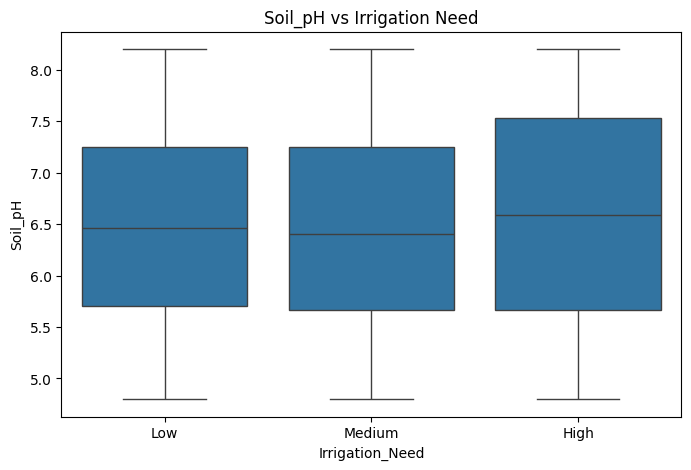

In [252]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x='Irrigation_Need', y='Soil_pH', data=data)
plt.title('Soil_pH vs Irrigation Need')
plt.show()

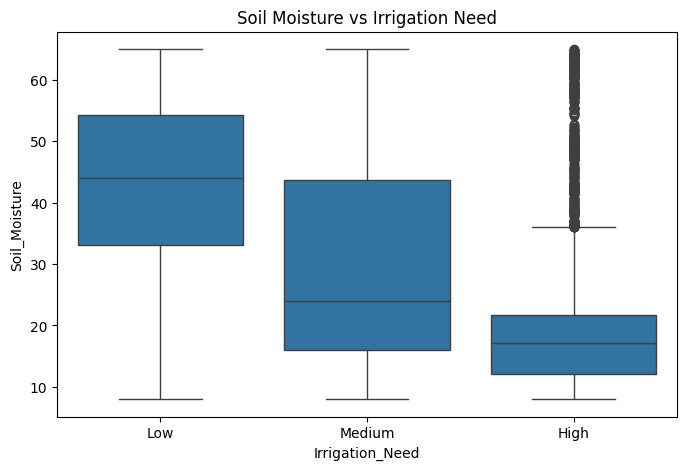

In [253]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x='Irrigation_Need', y='Soil_Moisture', data=data)
plt.title('Soil Moisture vs Irrigation Need')
plt.show()

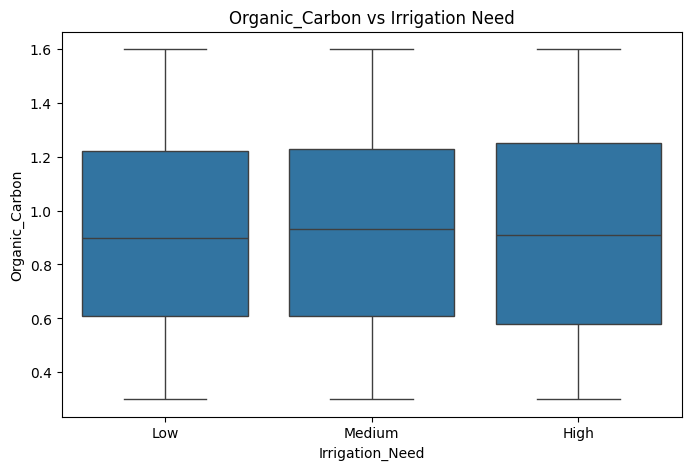

In [254]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x='Irrigation_Need', y='Organic_Carbon', data=data)
plt.title('Organic_Carbon vs Irrigation Need')
plt.show()

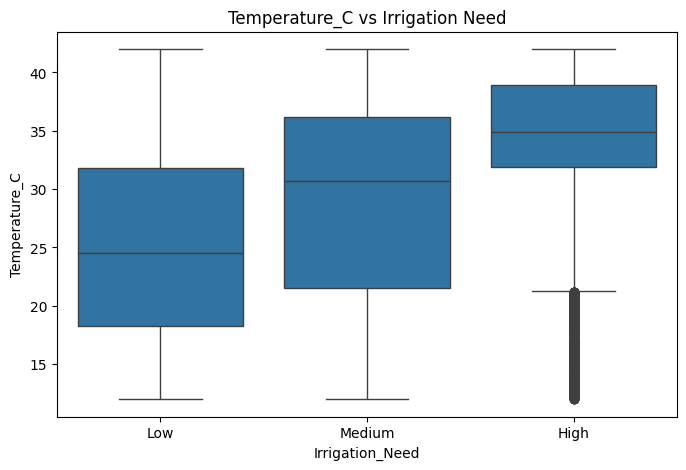

In [255]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x='Irrigation_Need', y='Temperature_C', data=data)
plt.title('Temperature_C vs Irrigation Need')
plt.show()

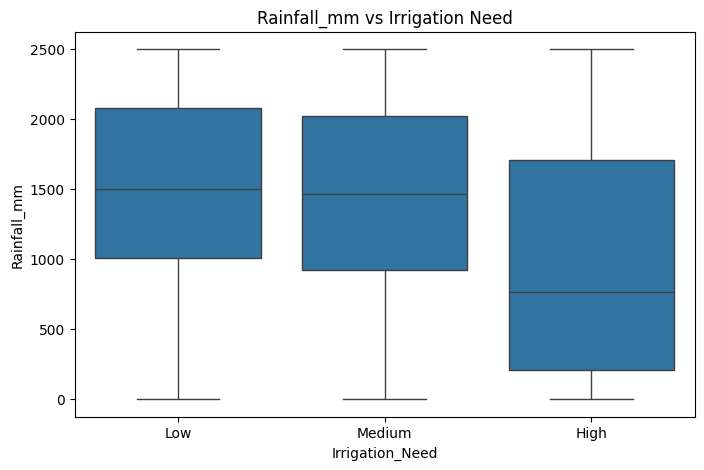

In [256]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x='Irrigation_Need', y='Rainfall_mm', data=data)
plt.title('Rainfall_mm vs Irrigation Need')
plt.show()

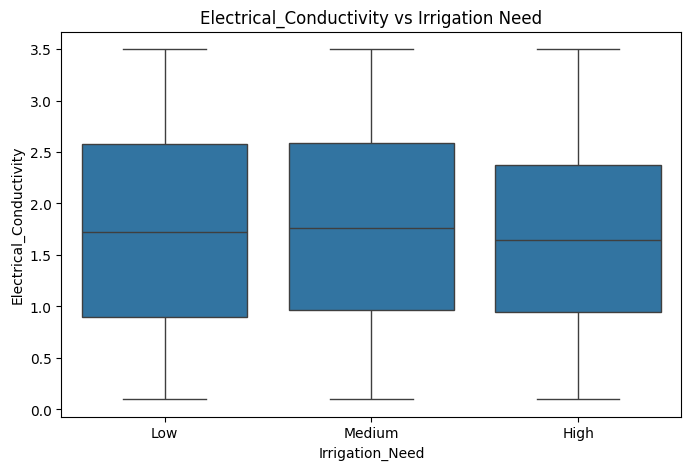

In [257]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x='Irrigation_Need', y='Electrical_Conductivity', data=data)
plt.title('Electrical_Conductivity vs Irrigation Need')
plt.show()

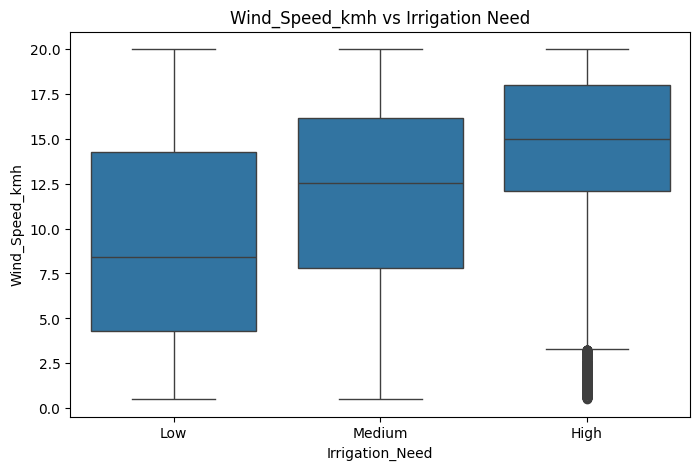

In [258]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x='Irrigation_Need', y='Wind_Speed_kmh', data=data)
plt.title('Wind_Speed_kmh vs Irrigation Need')
plt.show()

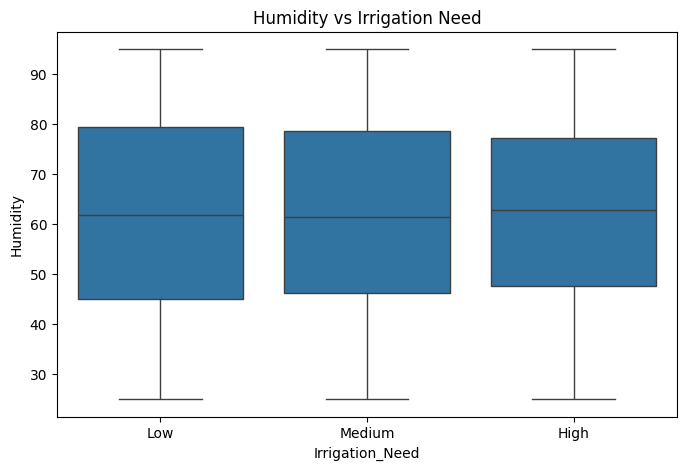

In [259]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x='Irrigation_Need', y='Humidity', data=data)
plt.title('Humidity vs Irrigation Need')
plt.show()

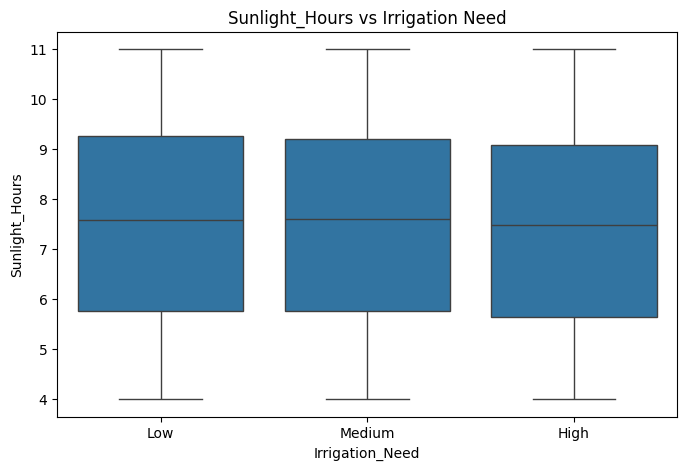

In [260]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x='Irrigation_Need', y='Sunlight_Hours', data=data)
plt.title('Sunlight_Hours vs Irrigation Need')
plt.show()

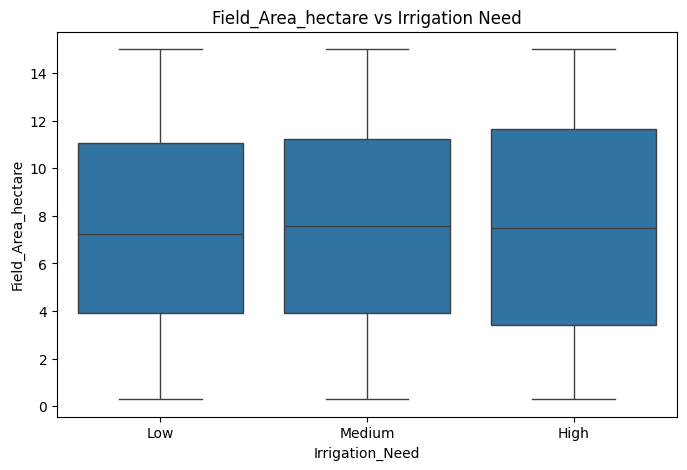

In [261]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x='Irrigation_Need', y='Field_Area_hectare', data=data)
plt.title('Field_Area_hectare vs Irrigation Need')
plt.show()

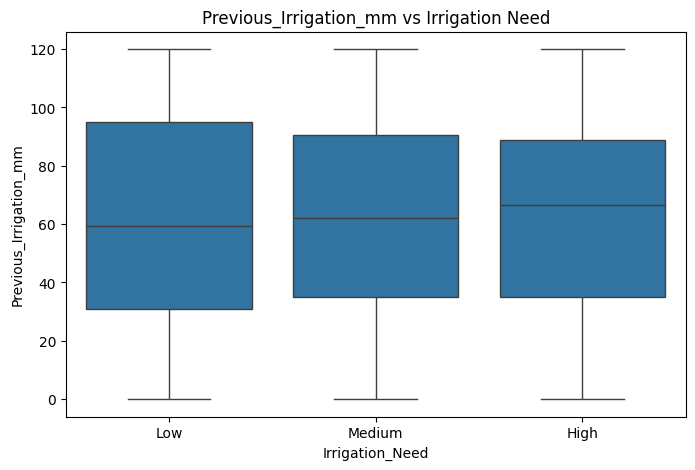

In [262]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x='Irrigation_Need', y='Previous_Irrigation_mm', data=data)
plt.title('Previous_Irrigation_mm vs Irrigation Need')
plt.show()

In [263]:
#new feature engineering
data['Temp_Humidity'] = data['Temperature_C'] * data['Humidity']
data['Soil_Temp_Ratio'] = data['Soil_Moisture'] / (data['Temperature_C'] + 1)
data['Rain_Temp_Interaction'] = data['Rainfall_mm'] * data['Temperature_C']
data['Wind_Humidity_Interaction'] = data['Wind_Speed_kmh'] / (data['Humidity'] + 1)
data['log_Soil']  = np.log1p(data['Soil_Moisture'])
data['sqrt_Rain'] = np.sqrt(data['Rainfall_mm'])
data['temp_squared'] = data['Temperature_C']**2
data['moisture_squared'] = data['Soil_Moisture'] ** 2


In [264]:
data['soil_Moisture_25'] = (data['Soil_Moisture'] < 25).astype(int)
data['Temperature_C_30'] = (data['Temperature_C'] > 30).astype(int)
data['Rainfall_mm_400'] = (data['Rainfall_mm'] < 400).astype(int)
data['Wind_Speed_kmh_10'] = (data['Wind_Speed_kmh'] > 10).astype(int)
data['humidity_low'] = (data['Humidity'] < 40).astype(int)

In [265]:
label_distribution=data['Irrigation_Need'].value_counts()
label_distribution

Irrigation_Need
Low       369917
Medium    239074
High       21009
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x7f2858d401a0>,
 [Text(-0.2974862462346723, 1.0590098834766388, 'Low'),
  Text(0.18511165827586887, -1.084312535190089, 'Medium'),
  Text(1.0939689635242145, -0.1150300258443689, 'High')],
 [Text(-0.16226522521891212, 0.5776417546236211, '58.7%'),
  Text(0.10096999542320119, -0.5914432010127758, '37.9%'),
  Text(0.5967103437404806, -0.06274365046056485, '3.3%')])

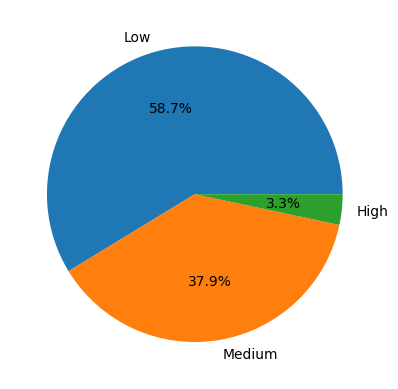

In [266]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.pie(x=label_distribution,labels=label_distribution.index,autopct='%1.1f%%',data=data)

In [267]:
data.describe()

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,...,Wind_Humidity_Interaction,log_Soil,sqrt_Rain,temp_squared,moisture_squared,soil_Moisture_25,Temperature_C_30,Rainfall_mm_400,Wind_Speed_kmh_10,humidity_low
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,...,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,6.482497,37.304482,0.922858,1.744605,26.998166,61.563180,1462.207566,7.513382,10.375394,7.517745,...,0.186379,3.529774,37.181473,803.267701,1659.832744,0.281497,0.404625,0.028389,0.526560,0.181124
std,0.922504,16.377082,0.365808,0.952321,8.623621,19.708152,612.989738,1.999322,5.689458,4.218124,...,0.129750,0.516337,8.930050,470.066793,1228.899591,0.449730,0.490820,0.166081,0.499294,0.385121
min,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,0.300000,...,0.005236,2.197225,0.616441,144.000000,64.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.690000,23.340000,0.610000,0.930000,19.517500,45.390000,954.570000,5.760000,5.280000,3.880000,...,0.087191,3.192121,30.896116,380.932825,544.755600,0.000000,0.000000,0.000000,0.000000,0.000000
50%,6.440000,37.750000,0.910000,1.740000,26.960000,61.650000,1467.160000,7.580000,10.480000,7.380000,...,0.167121,3.657131,38.303525,726.841600,1425.062500,0.000000,0.000000,0.000000,1.000000,0.000000
75%,7.270000,51.270000,1.220000,2.580000,34.540000,79.120000,2054.280000,9.250000,15.430000,11.140000,...,0.249932,3.956423,45.324166,1193.011600,2628.612900,1.000000,1.000000,0.000000,1.000000,0.000000
max,8.200000,64.990000,1.600000,3.500000,42.000000,94.990000,2499.690000,11.000000,20.000000,15.000000,...,0.763671,4.189503,49.996900,1764.000000,4223.700100,1.000000,1.000000,1.000000,1.000000,1.000000


<Axes: xlabel='Soil_Type', ylabel='count'>

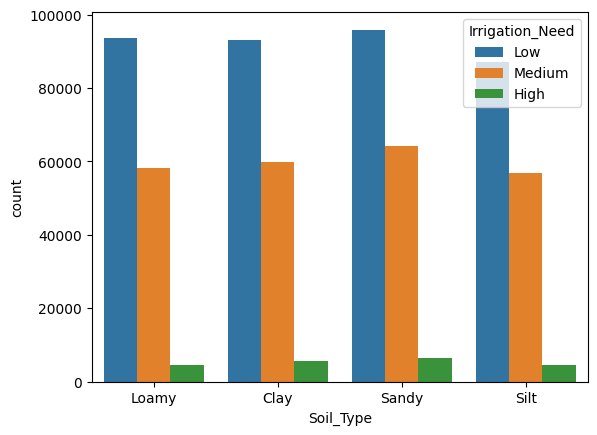

In [268]:
sns.countplot(x='Soil_Type',hue='Irrigation_Need',data=data)

In [269]:
# Mapping target column
data['Irrigation_Need']=data['Irrigation_Need'].map({'Low':0,'Medium':1,'High':2})

<Axes: >

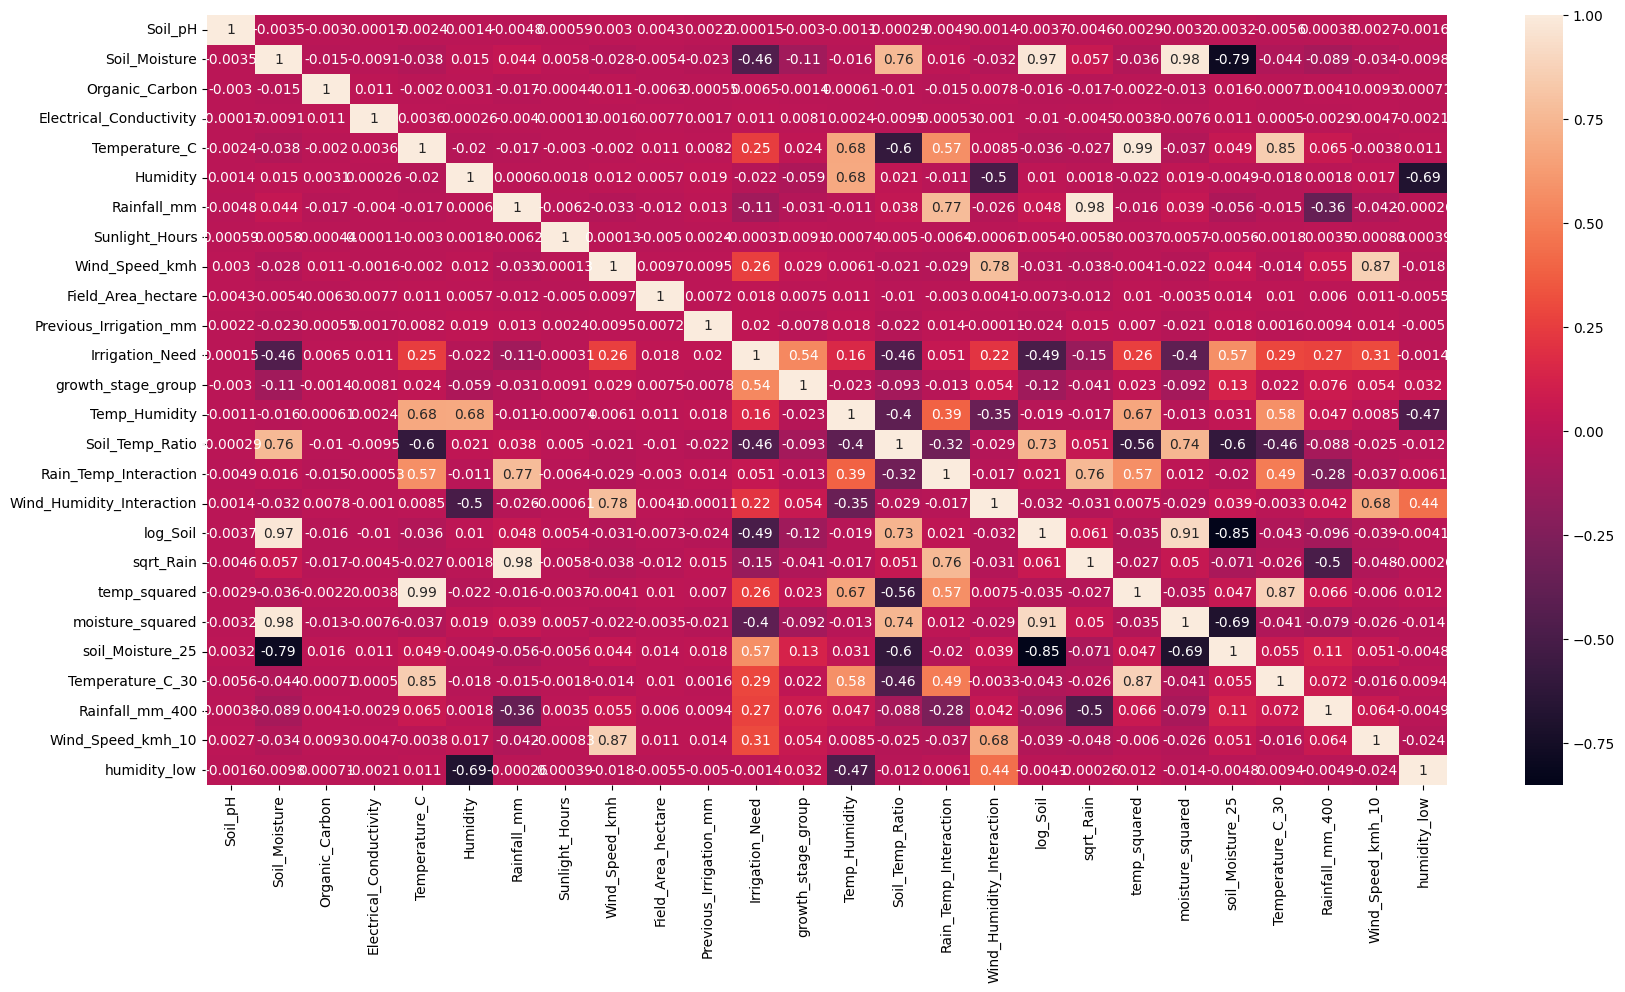

In [270]:
plt.figure(figsize=(20,10))
corr=data.select_dtypes(include=['float64','int64']).corr()
sns.heatmap(corr,annot=True)

In [271]:
x_train = data.drop('Irrigation_Need', axis=1)
y_train = data['Irrigation_Need']

In [272]:
from sklearn.preprocessing import StandardScaler ,OneHotEncoder

In [273]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
cat_cols = x_train.select_dtypes(include=['object']).columns
num_cols = x_train.select_dtypes(include=['float64','int64']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('cat',  OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', StandardScaler(), num_cols)
    ]
)
pipeline = Pipeline(steps=[('preprocessing', preprocessor)])

In [274]:
x_train_processed = pipeline.fit_transform(x_train)

In [275]:
import pandas as pd
from sklearn.preprocessing import StandardScaler , OrdinalEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import L1,L2
from tensorflow.keras.optimizers import Adam,SGD
from tensorflow.keras.callbacks import EarlyStopping

In [276]:
from sklearn.utils.class_weight import compute_class_weight
classes = np.unique(y_train)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)
class_weights_dict = dict(zip(classes, class_weights))
print("Class weights:", class_weights_dict)

Class weights: {np.int64(0): np.float64(0.5676949153458749), np.int64(1): np.float64(0.8783891180136694), np.int64(2): np.float64(9.995716121662145)}


In [277]:
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from sklearn.metrics import balanced_accuracy_score


In [278]:
model = Sequential([
    Dense(256, activation='relu', input_shape=(x_train_processed.shape[1],), kernel_regularizer=l2(1e-4)),
    #BatchNormalization(),
    #Dropout(0.3),
    
    Dense(128, activation='relu', kernel_regularizer=l2(1e-4)),
    #BatchNormalization(),
    #Dropout(0.3),
    
    Dense(64, activation='relu', kernel_regularizer=l2(1e-4)),   
    #BatchNormalization(),
    #Dropout(0.25),
    
    Dense(64, activation='relu', kernel_regularizer=l2(1e-4)),
    #BatchNormalization(),
    #Dropout(0.2),
    
    Dense(32, activation='relu', kernel_regularizer=l2(1e-4)),
    #BatchNormalization(),
    
    Dense(3, activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [279]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_25 (Dense)                │ (None, 256)            │        14,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,339 (243.51 KB)

 Trainable params: 62,339 (243.51 KB)

 Non-trainable params: 0 (0.00 B)

# test data

In [280]:
test_data=pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/test.csv')

In [281]:
test_data.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region
0,630000,Silt,6.36,26.19,0.59,2.81,17.83,30.24,1533.38,5.40,3.00,Maize,Sowing,Rabi,Canal,River,13.59,Yes,47.48,West
1,630001,Clay,5.87,9.88,1.18,3.26,21.18,78.07,576.05,7.22,15.88,Cotton,Sowing,Rabi,Drip,Reservoir,6.12,Yes,56.43,South
2,630002,Sandy,6.22,26.55,0.96,0.85,26.87,60.35,545.30,9.43,2.63,Wheat,Sowing,Kharif,Sprinkler,Reservoir,3.11,Yes,20.00,East
3,630003,Clay,7.68,53.58,0.83,0.55,41.74,36.05,1211.03,6.69,1.86,Maize,Harvest,Rabi,Canal,Groundwater,2.27,No,102.99,North
4,630004,Loamy,5.23,59.02,0.54,2.11,41.08,52.47,1321.91,4.11,5.71,Cotton,Sowing,Kharif,Canal,Groundwater,12.39,Yes,13.33,Central


In [282]:
(data.isnull().sum())/len(data)*100

Soil_Type                    0.0
Soil_pH                      0.0
Soil_Moisture                0.0
Organic_Carbon               0.0
Electrical_Conductivity      0.0
Temperature_C                0.0
Humidity                     0.0
Rainfall_mm                  0.0
Sunlight_Hours               0.0
Wind_Speed_kmh               0.0
Crop_Type                    0.0
Crop_Growth_Stage            0.0
Season                       0.0
Irrigation_Type              0.0
Water_Source                 0.0
Field_Area_hectare           0.0
Mulching_Used                0.0
Previous_Irrigation_mm       0.0
Region                       0.0
Irrigation_Need              0.0
growth_stage_group           0.0
Temp_Humidity                0.0
Soil_Temp_Ratio              0.0
Rain_Temp_Interaction        0.0
Wind_Humidity_Interaction    0.0
log_Soil                     0.0
sqrt_Rain                    0.0
temp_squared                 0.0
moisture_squared             0.0
soil_Moisture_25             0.0
Temperatur

In [283]:
test_ids = test_data['id']

In [284]:
test_data.drop('id',axis=1,inplace=True)

In [285]:
test_data['Temp_Humidity'] = test_data['Temperature_C'] * test_data['Humidity']
test_data['Soil_Temp_Ratio'] =test_data['Soil_Moisture'] / (test_data['Temperature_C'] + 1)
test_data['Rain_Temp_Interaction'] = test_data['Rainfall_mm'] * test_data['Temperature_C']
test_data['Wind_Humidity_Interaction'] = test_data['Wind_Speed_kmh'] / (test_data['Humidity'] + 1)
test_data['log_Soil']  = np.log1p(test_data['Soil_Moisture'])
test_data['sqrt_Rain'] = np.sqrt(test_data['Rainfall_mm'])
test_data['temp_squared'] = test_data['Temperature_C']**2
test_data['moisture_squared'] = test_data['Soil_Moisture'] ** 2
test_data['soil_Moisture_25'] = (test_data['Soil_Moisture'] < 25).astype(int)
test_data['Temperature_C_30'] = (test_data['Temperature_C'] > 30).astype(int)
test_data['Rainfall_mm_400'] = (test_data['Rainfall_mm'] < 400).astype(int)
test_data['Wind_Speed_kmh_10'] = (test_data['Wind_Speed_kmh'] > 10).astype(int)
test_data['humidity_low'] = (test_data['Humidity'] < 40).astype(int)
test_data['growth_stage_group'] = test_data['Crop_Growth_Stage'].map({
    'Sowing': 0,
    'Harvest': 0,
    'Vegetative': 1,
    'Flowering': 1
})

In [286]:
test_processed = pipeline.transform(test_data)

In [287]:
early_stopping = EarlyStopping(patience=8, monitor='val_loss', restore_best_weights=True)

In [288]:
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.models import clone_model
import numpy as np
import pandas as pd

N_FOLD = 5
skf = StratifiedKFold(n_splits=N_FOLD, shuffle=True, random_state=42)

test_preds_folds = []

fold_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(x_train_processed, y_train)):
    print(f"Training fold {fold+1}/{N_FOLD}")
    
    X_tr, X_val = x_train_processed[train_idx], x_train_processed[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    # Clone the model 
    model_fold = clone_model(model)
    model_fold.compile(
        optimizer=Adam(learning_rate=0.0005),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # Train
    model_fold.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=80,
        batch_size=512,
        callbacks=[early_stopping],
        class_weight=class_weights_dict,
        verbose=1
    )
    
    # Validation accuracy
    val_pred = model_fold.predict(X_val).argmax(axis=1)
    acc = (val_pred == y_val).mean()
    fold_scores.append(acc)
    print(f"Fold {fold+1} accuracy: {acc:.4f}")
    
    # Predict on test set
    test_preds_fold = model_fold.predict(test_processed)
    test_preds_folds.append(test_preds_fold)

Training fold 1/5
Epoch 1/80
985/985 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9169 - loss: 0.2811 - val_accuracy: 0.9780 - val_loss: 0.1217
Epoch 2/80
985/985 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9763 - loss: 0.1400 - val_accuracy: 0.9744 - val_loss: 0.1232
Epoch 3/80
985/985 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9782 - loss: 0.1287 - val_accuracy: 0.9828 - val_loss: 0.0975
Epoch 4/80
985/985 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9778 - loss: 0.1252 - val_accuracy: 0.9796 - val_loss: 0.1078
Epoch 5/80
985/985 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9779 - loss: 0.1215 - val_accuracy: 0.9733 - val_loss: 0.1135
Epoch 6/80
985/985 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9782 - loss: 0.1194 - val_accuracy: 0.9809 - val_loss: 0.0990
Epoch 7/80
985/985 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9788 - loss: 0.1119 - val_accuracy: 0.9821 - val_loss: 0.0924
Epoch 8/80
985/985 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9797 - loss: 0.1086 

In [289]:
# Average predictions across folds
test_preds_avg = np.mean(test_preds_folds, axis=0)
y_test_pred = test_preds_avg.argmax(axis=1)

In [290]:
label_map = {0: 'Low', 1: 'Medium', 2: 'High'}
y_pred_labels = [label_map[i] for i in y_test_pred]

In [291]:
submission = pd.DataFrame({
    'id': test_ids,
    'Irrigation_Need': y_pred_labels
})

In [292]:
submission.to_csv('submission_kfold.csv', index=False)

In [293]:
print("Mean K-Fold Accuracy on training set:", np.mean(fold_scores))

Mean K-Fold Accuracy on training set: 0.9824714285714287
